In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

In [9]:
# read the LLM priors

price_priors =  pd.read_csv("../../data/results/experiment_3a_v2.csv")
affect_priors =  pd.read_csv("../../data/results/experiment_3b_v2.csv")

In [35]:
affect_priors
price_priors

,item,prices,rating
0,electric kettle,50,0.75
1,electric kettle,48,0.50
2,electric kettle,500,0.25
3,electric kettle,501,0.25
4,electric kettle,1000,0.00
5,electric kettle,999,0.00
6,electric kettle,5000,0.00
7,electric kettle,4998,0.00
8,electric kettle,10000,0.00
9,electric kettle,9998,0.00


In [11]:
def match_humans_to_model(state):
    if state == 51:
        return 48
    elif state == 1001:
        return 999
    elif state == 5001:
        return 4998
    elif state == 10001:
        return 9998
    else:
        return state

In [12]:
affect_priors['prices'] = price_priors['prices'].apply(match_humans_to_model)
price_priors['prices'] = price_priors['prices'].apply(match_humans_to_model)

In [5]:
# TODO read in the utterance probabilities
speaker_probs = pd.read_csv('../../data/results_pt/experiment_1b_raw/gpt-4o-mini_speaker_mean_probs.csv')
speaker_probs

,item,affect,goal,affect_valence,state,utterance,utterance_prob
0,electric kettle,-,s_exact,0,48,48,0.124443
1,electric kettle,-,s_exact,0,48,50,0.010708
2,electric kettle,-,s_exact,0,48,500,0.003939
3,electric kettle,-,s_exact,0,48,501,0.003939
4,electric kettle,-,s_exact,0,48,999,0.003939
...,...,...,...,...,...,...,...
2395,watch,a,s_fuzzy,1,10000,1000,0.014223
2396,watch,a,s_fuzzy,1,10000,4998,0.014223
2397,watch,a,s_fuzzy,1,10000,5000,0.014223
2398,watch,a,s_fuzzy,1,10000,9998,0.014223


In [236]:
# calculate the posterior
# (s, a) ordered as iteration over states for a = 0, then for a = 1
# TODO take note of how normalization will neeed to take place (which will be oever the utterances for each [i] for i in len(probs))
posteriors = {
    "electric kettle":
    {"$48": [],
    "$50": [],
    "$500": [],
    "$501": [],
    "$999": [],
    "$1000": [],
    "$4998": [],
    "$5000": [],
    "$9998": [],
    "$10000": []
    },
    "watch": {"$48": [],
    "$50": [],
    "$500": [],
    "$501": [],
    "$999": [],
    "$1000": [],
    "$4998": [],
    "$5000": [],
    "$9998": [],
    "$10000": []
    },
    "laptop": {"$48": [],
    "$50": [],
    "$500": [],
    "$501": [],
    "$999": [],
    "$1000": [],
    "$4998": [],
    "$5000": [],
    "$9998": [],
    "$10000": []
    }
}

conditions = [
    "a-only-0", # this subsumes s_exact and s_fuzzy -- TODO: find out if it needs to be split for correct expectation calculation
    "a-only-1", # this subsumes s_exact and s_fuzzy -- TODO: find out if it needs to be split for correct expectation calculation
    "only-s_exact-0", # this and the next should have valence 1, but it's equivalent to 0, so it's just a replication
    "only-s_exact-0",
    "only-s_fuzzy-0", # same
    "only-s_fuzzy-0",
    "a-s_exact-0",
    "a-s_exact-1",
    "a-s_fuzzy-0",
    "a-s_fuzzy-1",
]

# conditions = [
#     # "a-only-0", # this subsumes s_exact and s_fuzzy -- TODO: find out if it needs to be split for correct expectation calculation
#     "a-only", # this subsumes s_exact and s_fuzzy -- TODO: find out if it needs to be split for correct expectation calculation
#     "only-s_exact", # this and the next should have valence 1, but it's equivalent to 0, so it's just a replication
#     # "only-s_exact-0",
#     "only-s_fuzzy", # same
#     # "only-s_fuzzy-0",
#     # "a-s_exact-0",
#     "a-s_exact",
#     # "a-s_fuzzy-0",
#     "a-s_fuzzy",
# ]

states = price_priors["prices"].unique().tolist()
# TODO: make sure the states are by-object too

# iterate over objects
for obj in posteriors.keys():
    # iterate over utterances
    for u in posteriors[obj].keys():
        u = int(u.replace("$", ""))
        # iterate over goals
        #### TODO ###### norm accross utterances by state-val pairs
        # for val in ["0", "1"]:
        for s in states:
                goal_probs_list = []
                for goal in conditions:
                    # goal = goal + "-" + val
                    # # catch those cases where we didn't collect separate data
                    # if (goal == "only-s_exact-1"):
                    #     goal = "only-s_exact-0" 
                    # elif (goal == "only-s_fuzzy-1"):
                    #     goal = "only-s_fuzzy-0"

                # s = int(s.replace("$", ""))
                
                # pull the respective affect prior
                    affect_s = affect_priors[affect_priors['prices'] == s]
                    affect_s_i = affect_s[affect_s['item'] == obj]["rating"].values[0]
                    # pull the state prior
                    price_s = price_priors[price_priors['prices'] == s]
                    price_s_i = price_s[price_s['item'] == obj]["rating"].values[0]
                    # pull the speaker probability
                    print('u s obj ', u, s, obj)
                    p_u = speaker_probs[
                        (speaker_probs['utterance'] == u) &
                        (speaker_probs['state'] == s) &
                        (speaker_probs['item'] == obj)
                    ]
                    # retrieve the correct goal
                    a_setting = "-" if goal.split("-")[0] == "only" else goal.split("-")[0]
                    s_setting = "-" if goal.split("-")[1] == "only" else goal.split("-")[1]
                    affect_valence = int(goal.split("-")[2])
                    print("Goal substrings ", a_setting, s_setting, affect_valence)
                    
                    p_u_goal = p_u[
                        (p_u['affect'] == a_setting) &
                        (p_u['goal'] == s_setting) &
                        (p_u['affect_valence'] == affect_valence)
                    ]['utterance_prob'].values[0]
                    print("p_u_goal ", p_u_goal)
                    print("affect_s_i ", affect_s_i)
                    print("price_s_i ", price_s_i)
                    # calculate the posterior
                    posterior_prob = p_u_goal * affect_s_i * price_s_i
                    # goal_probs_list.append(posterior_prob)
                ### sum over goals
                # s_posterior_prob = sum(goal_probs_list)
                    # append
                    posteriors[obj]["$" + str(u)].append(posterior_prob)
                

u s obj  48 50 electric kettle
Goal substrings  a - 0
p_u_goal  0.0142227904317764
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  a - 1
p_u_goal  0.0142227904317764
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  - s_exact 0
p_u_goal  0.0026206213007738
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  - s_exact 0
p_u_goal  0.0026206213007738
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  - s_fuzzy 0
p_u_goal  0.0337174729326408
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  - s_fuzzy 0
p_u_goal  0.0337174729326408
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  a s_exact 0
p_u_goal  0.0057302248573515
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrings  a s_exact 1
p_u_goal  0.0142227904317764
affect_s_i  0.5
price_s_i  0.75
u s obj  48 50 electric kettle
Goal substrin

In [270]:
# len(posteriors["electric kettle"]['$48'])

100

In [284]:
import math

def softmax_with_alpha(values, alpha=100.0):
    """
    Compute the softmax of a list of values with an alpha scaling parameter.

    Args:
        values (list): A list of numeric values.
        alpha (float): Scaling parameter for sharpness/smoothness (default = 1.0).

    Returns:
        list: Softmax probabilities.
    """
    # Subtract the max value for numerical stability
    # max_val = max(values)
    exp_values = [math.exp(alpha * v ) for v in values]
    total = sum(exp_values)
    return [v / total for v in exp_values]

In [238]:
from scipy.special import softmax
## normalize the probs over utterances, for each index in the list of utterances
posteriors_normalized = posteriors.copy()

# Apply softmax to the `posteriors` dictionary
for product, prices in posteriors_normalized.items():
    # Transpose the data to work index-wise
    num_indices = len(next(iter(prices.values())))  # Number of indices (length of lists)
    for i in range(num_indices):
        # Collect all values at index `i` across all price points
        values_at_index = [prices[price][i] for price in prices]
        # Apply the softmax function
        softmax_values = softmax_with_alpha(values_at_index)
        # Assign softmax values back to their respective price keys
        for j, price in enumerate(prices):
            prices[price][i] = softmax_values[j]

print(posteriors_normalized)

{'electric kettle': {'$48': [0.0001045884304493571, 0.0001045884304493571, 1.332140459674591e-23, 1.332140459674591e-23, 0.49932498065445113, 0.49932498065445113, 1.5447697791090313e-18, 0.0001045884304493571, 2.6212207988927555e-11, 0.0001045884304493571, 0.4904808679255306, 0.4904808679255306, 0.9999999999988923, 0.9999999999988923, 6.275702183019666e-11, 6.275702183019666e-11, 0.9999999999273907, 0.957666097796171, 0.9030115791685988, 0.4904808679255306, 0.009368927586551511, 0.009368927586551511, 3.649849941555234e-12, 3.649849941555234e-12, 0.009368927586551511, 0.009368927586551511, 1.0226424509391886e-07, 0.009368927586551511, 0.0019096731306160206, 0.009368927586551511, 0.008562293323470641, 0.008562293323470641, 8.902195262793976e-11, 8.902195262793976e-11, 3.901192727631612e-09, 3.901192727631612e-09, 1.397029129374371e-07, 0.008562293323470641, 0.00010863150782704238, 0.008562293323470641, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0

In [239]:
len(posteriors_normalized['electric kettle']['$48'])

100

In [240]:
# map the posteriors back onto the state x goal conditions
affect_replicated = [item for item in [0, 1] for _ in range(10)]
goal_replicated = [item for item in conditions for _ in range(10)]
states_replicated = states * 10
len(states_replicated)
# make a df from the posteriors_normalized and add the goals and states list
posteriors_df = pd.DataFrame(posteriors_normalized)


In [241]:
len(states_replicated)

100

In [242]:
# posteriors_df["affect_values"] = [affect_replicated] * 10
posteriors_df["goals"] = [goal_replicated] * 10
posteriors_df["states"] = [states_replicated] * 10

In [243]:
posteriors_df.rename_axis('utterance', inplace=True)

In [244]:
posteriors_df_long = posteriors_df.explode(['electric kettle', 'watch', 'laptop', 'goals', 'states']).reset_index()

In [245]:
posteriors_df_long

,utterance,electric kettle,watch,laptop,goals,states
0,$48,0.000105,0.000001,0.1,a-only-0,50
1,$48,0.000105,0.002178,0.1,a-only-0,48
2,$48,0.0,0.0,0.1,a-only-0,500
3,$48,0.0,0.0,0.1,a-only-0,501
4,$48,0.499325,0.000021,0.1,a-only-0,1000
...,...,...,...,...,...,...
995,$10000,0.1,0.499972,0.98372,a-s_fuzzy-1,999
996,$10000,0.1,0.000001,0.0,a-s_fuzzy-1,5000
997,$10000,0.1,0.994921,0.609329,a-s_fuzzy-1,4998
998,$10000,0.1,1.0,0.99955,a-s_fuzzy-1,10000


In [246]:
# categorize the state utterance pairs

def categorize_s_u_pair(row):
    state = row["states"]
    utterance = row["utterance"]
    utterance = int(utterance.replace("$", ""))
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 4:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation


In [247]:
posteriors_df_long_categorized = posteriors_df_long.copy()
posteriors_df_long_categorized["interpretation"] = posteriors_df_long_categorized.apply(categorize_s_u_pair, axis=1)

In [248]:
# marginalize over affect values 
posteriors_df_long_categorized_objectsCombined = posteriors_df_long_categorized.melt(id_vars=['utterance', 'goals', 'states', 'interpretation'], value_vars=['electric kettle', 'watch', 'laptop'], var_name='object', value_name='posterior')

In [249]:
posteriors_df_long_categorized_objectsCombined

,utterance,goals,states,interpretation,object,posterior
0,$48,a-only-0,50,fuzzy,electric kettle,0.000105
1,$48,a-only-0,48,exact,electric kettle,0.000105
2,$48,a-only-0,500,other,electric kettle,0.0
3,$48,a-only-0,501,other,electric kettle,0.0
4,$48,a-only-0,1000,other,electric kettle,0.499325
...,...,...,...,...,...,...
2995,$10000,a-s_fuzzy-1,999,hyperbolic,laptop,0.98372
2996,$10000,a-s_fuzzy-1,5000,hyperbolic,laptop,0.0
2997,$10000,a-s_fuzzy-1,4998,hyperbolic,laptop,0.609329
2998,$10000,a-s_fuzzy-1,10000,exact,laptop,0.99955


In [285]:
posteriors_df_long_categorized_objectsCombined_marginal_s = posteriors_df_long_categorized_objectsCombined.copy()

posteriors_df_long_categorized_objectsCombined_marginal_s = posteriors_df_long_categorized_objectsCombined_marginal_s.groupby(
    ['utterance', 'states', 'interpretation', 'object'] 
)['posterior'].sum().reset_index()

# posteriors_df_long_categorized_objectsCombined_marginal_s['posterior'] = posteriors_df_long_categorized_objectsCombined_marginal_s['posterior'].apply(lambda x: float(x))

posteriors_df_long_categorized_objectsCombined_marginal_s_probs = (
    posteriors_df_long_categorized_objectsCombined_marginal_s
    .groupby(['utterance', 'states', 'object', 'interpretation'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        # 'utterance': x['utterance'].tolist(),
        'posterior': softmax_with_alpha(x['posterior'])
    }))
    .reset_index(level=[0, 1, 2, 3])  # Reset only the grouping indices
)

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_79439/617963190.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


In [232]:
posteriors_df_long_categorized_objectsCombined_marginal_s_probs['posterior'].unique

array([1.14684127e-05, 1.13490915e-05, 2.89633273e-05, ...,
       9.91138686e-02, 9.91138651e-02, 9.91141127e-02])

In [234]:
posteriors_df_long_categorized_objectsCombined_marginal_s_sorted['posterior'].unique()


array([4.99912915e-22, 2.29345585e-05, 2.26959395e-05, ...,
       1.92721489e-43, 4.83602534e-43, 2.40410746e-43])

In [183]:
# posteriors_df_long_categorized_objectsCombined_marginal_s_probs["interpretation"] = posteriors_df_long_categorized_objectsCombined_marginal_s.apply(categorize_s_u_pair, axis=1)

In [252]:
posteriors_df_long_categorized_objectsCombined_marginal_s['utterance'] = posteriors_df_long_categorized_objectsCombined_marginal_s["utterance"].apply(lambda x: int(x.replace("$", "")))
posteriors_df_long_categorized_objectsCombined_marginal_s_sorted = posteriors_df_long_categorized_objectsCombined_marginal_s.sort_values("utterance")

In [229]:
posteriors_df_long_categorized_objectsCombined_marginal_s_sorted['interpretation'].unique()

array(['other', 'fuzzy', 'exact', 'hyperbolic'], dtype=object)

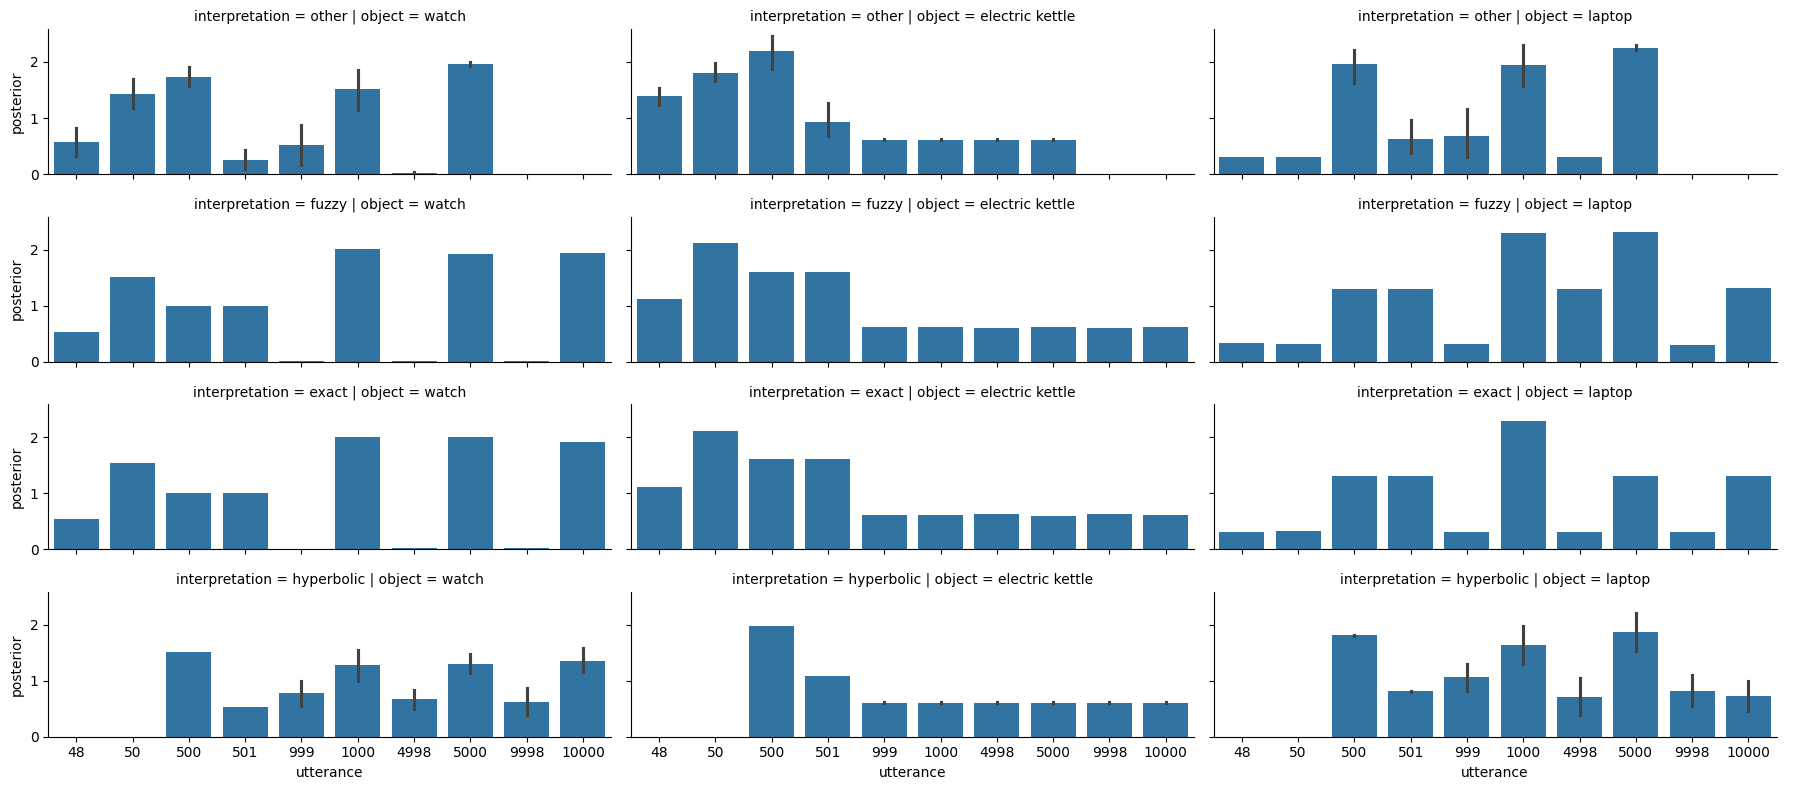

In [253]:
p = sns.FacetGrid(posteriors_df_long_categorized_objectsCombined_marginal_s_sorted, col="object", row="interpretation", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "posterior")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [264]:
# posteriors_df_long_categorized_objectsCombined_marginal_s["utterance"] = posteriors_df_long_categorized_objectsCombined_marginal_s["utterance"].apply(lambda x: int(x.replace("$", "")))
posteriors_df_long_categorized_objectsCombined_marginal_a = posteriors_df_long_categorized_objectsCombined.copy()
posteriors_df_long_categorized_objectsCombined_marginal_a["affect_valence"] = posteriors_df_long_categorized_objectsCombined_marginal_a["goals"].apply(lambda x: int(x.split("-")[2]))
posteriors_df_long_categorized_objectsCombined_marginal_a["goals"] = posteriors_df_long_categorized_objectsCombined_marginal_a["goals"].apply(lambda x: x.split("-")[0] + "-" + x.split("-")[1])

posteriors_df_long_categorized_objectsCombined_marginal_a = posteriors_df_long_categorized_objectsCombined_marginal_a.groupby(
    ['utterance', 'affect_valence', 'object'] # ['utterance', 'affect_valence', 'interpretation', 'object', 'goals']
)['posterior'].sum().reset_index()
posteriors_df_long_categorized_objectsCombined_marginal_a_probs = (
    posteriors_df_long_categorized_objectsCombined_marginal_a
    .groupby(['utterance', 'object'])
    .apply(lambda x: pd.DataFrame({
        # 'affect': x['affect'].tolist(),
        # 'goal': x['goal'].tolist(),
        # 'affect_valence': x['affect_valence'].tolist(),
        # 'utterance': x['utterance'].tolist(),
        'posterior': softmax_with_alpha(x['posterior'], 1)
    }))
    .reset_index(level=[0, 1, 2])  # Reset only the grouping indices
)

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_79439/3718379636.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


In [265]:
posteriors_df_long_categorized_objectsCombined_marginal_a_probs


,utterance,object,level_2,posterior
0,$1000,electric kettle,0,8.892075e-01
1,$1000,electric kettle,1,1.107925e-01
2,$1000,laptop,0,9.999999e-01
3,$1000,laptop,1,9.228802e-08
4,$1000,watch,0,9.999997e-01
5,$1000,watch,1,3.032085e-07
6,$10000,electric kettle,0,8.892075e-01
7,$10000,electric kettle,1,1.107925e-01
8,$10000,laptop,0,1.296268e-02
9,$10000,laptop,1,9.870373e-01


In [266]:
posteriors_df_long_categorized_objectsCombined_marginal_a_probs["utterance"] = posteriors_df_long_categorized_objectsCombined_marginal_a_probs["utterance"].apply(lambda x: int(x.replace("$", ""))) 
posteriors_df_long_categorized_objectsCombined_marginal_a_sorted = posteriors_df_long_categorized_objectsCombined_marginal_a_probs.sort_values("utterance")

In [141]:
posteriors_df_long_categorized_objectsCombined_marginal_a2 = posteriors_df_long_categorized_objectsCombined.copy()
posteriors_df_long_categorized_objectsCombined_marginal_a2["affect_valence"] = posteriors_df_long_categorized_objectsCombined_marginal_a2["goals"].apply(lambda x: int(x.split("-")[2]))
posteriors_df_long_categorized_objectsCombined_marginal_a2["goals"] = posteriors_df_long_categorized_objectsCombined_marginal_a2["goals"].apply(lambda x: x.split("-")[0] + "-" + x.split("-")[1])
posteriors_df_long_categorized_objectsCombined_marginal_a2 = posteriors_df_long_categorized_objectsCombined_marginal_a2[posteriors_df_long_categorized_objectsCombined_marginal_a2["affect_valence"] == 1]

In [142]:
posteriors_df_long_categorized_objectsCombined_marginal_a2

,utterance,goals,states,interpretation,object,posterior,affect_valence
10,$48,a-only,50,fuzzy,electric kettle,0.086761,1
11,$48,a-only,48,exact,electric kettle,0.149623,1
12,$48,a-only,500,other,electric kettle,0.094471,1
13,$48,a-only,501,other,electric kettle,0.091018,1
14,$48,a-only,1000,other,electric kettle,0.1,1
...,...,...,...,...,...,...,...
2995,$10000,a-s_fuzzy,999,hyperbolic,laptop,0.045358,1
2996,$10000,a-s_fuzzy,5000,hyperbolic,laptop,0.094471,1
2997,$10000,a-s_fuzzy,4998,hyperbolic,laptop,0.060828,1
2998,$10000,a-s_fuzzy,10000,exact,laptop,0.1,1


In [268]:
posteriors_df_long_categorized_objectsCombined_marginal_a_sorted

,utterance,object,level_2,posterior
14,48,laptop,0,7.298415e-01
17,48,watch,1,9.954076e-01
16,48,watch,0,4.592413e-03
15,48,laptop,1,2.701585e-01
13,48,electric kettle,1,9.623328e-01
12,48,electric kettle,0,3.766720e-02
27,50,laptop,1,2.701585e-01
26,50,laptop,0,7.298415e-01
25,50,electric kettle,1,5.505648e-04
24,50,electric kettle,0,9.994494e-01


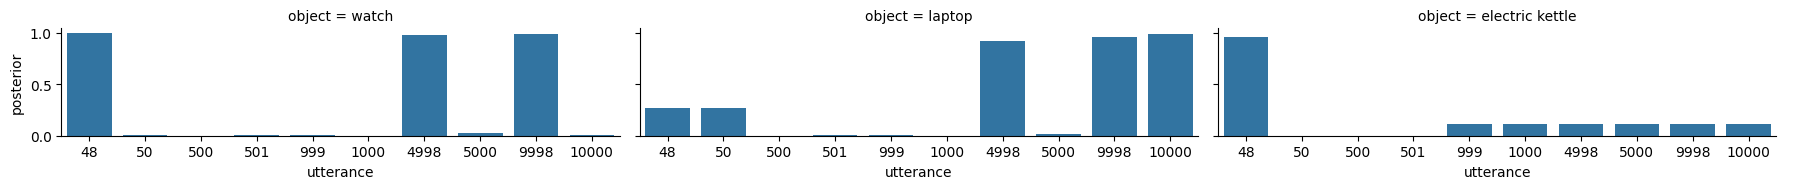

In [269]:
# posteriors_df_long_categorized_objectsCombined_marginal_a2
p = sns.FacetGrid( posteriors_df_long_categorized_objectsCombined_marginal_a_sorted[posteriors_df_long_categorized_objectsCombined_marginal_a_sorted['level_2'] == 1] , col="object", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "posterior")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
p.add_legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [271]:
# final attempt to marginalize over goals and states
posteriors_df_long_categorized_objectsCombined_marginal = posteriors_df_long_categorized_objectsCombined.copy()
posteriors_df_long_categorized_objectsCombined_marginal["affect_valence"] = posteriors_df_long_categorized_objectsCombined_marginal["goals"].apply(lambda x: int(x.split("-")[2]))
posteriors_df_long_categorized_objectsCombined_marginal["goals"] = posteriors_df_long_categorized_objectsCombined_marginal["goals"].apply(lambda x: x.split("-")[0] + "-" + x.split("-")[1])

posteriors_df_long_categorized_objectsCombined_marginal

,utterance,goals,states,interpretation,object,posterior,affect_valence
0,$48,a-only,50,fuzzy,electric kettle,0.000105,0
1,$48,a-only,48,exact,electric kettle,0.000105,0
2,$48,a-only,500,other,electric kettle,0.0,0
3,$48,a-only,501,other,electric kettle,0.0,0
4,$48,a-only,1000,other,electric kettle,0.499325,0
...,...,...,...,...,...,...,...
2995,$10000,a-s_fuzzy,999,hyperbolic,laptop,0.98372,1
2996,$10000,a-s_fuzzy,5000,hyperbolic,laptop,0.0,1
2997,$10000,a-s_fuzzy,4998,hyperbolic,laptop,0.609329,1
2998,$10000,a-s_fuzzy,10000,exact,laptop,0.99955,1


In [272]:
# marginalize overe states and goals
posteriors_df_long_categorized_objectsCombined_marginal.groupby(
    ['utterance', 'object', 'affect_valence'] # ['utterance', 'affect_valence', 'interpretation', 'object', 'goals']
)['posterior'].sum().reset_index()

,utterance,object,affect_valence,posterior
0,$1000,electric kettle,0,4.093237
1,$1000,electric kettle,1,2.010566
2,$1000,laptop,0,17.538338
3,$1000,laptop,1,1.339987
4,$1000,watch,0,15.081459
5,$1000,watch,1,0.072614
6,$10000,electric kettle,0,4.093237
7,$10000,electric kettle,1,2.010566
8,$10000,laptop,0,2.030405
9,$10000,laptop,1,6.363039


In [276]:
human_data = pd.read_csv("../../human_data/experiment1-normalized.csv")
human_data

def match_humans_to_model(state):
    if state == 51:
        return 48
    elif state == 1001:
        return 999
    elif state == 5001:
        return 4998
    elif state == 10001:
        return 9998
    else:
        return state
    
human_data_summary = human_data.groupby(["domain", "utterance", "state"]).mean("stateProb").reset_index()
    
human_data_summary["matched_state"] = human_data_summary["state"].apply(match_humans_to_model)  

human_data_summary_subset = human_data_summary[["domain", "utterance", "matched_state", "stateProb"]]
human_data_summary_subset = human_data_summary_subset.rename(columns={"matched_state": "state", "stateProb": "human_prob", "domain": "object"})


In [277]:
human_data_summary_subset

,object,utterance,state,human_prob
0,electric kettle,50,50,0.418484
1,electric kettle,50,48,0.378516
2,electric kettle,50,500,0.055859
3,electric kettle,50,501,0.053655
4,electric kettle,50,1000,0.023735
...,...,...,...,...
295,watch,10001,999,0.079112
296,watch,10001,5000,0.077224
297,watch,10001,4998,0.075499
298,watch,10001,10000,0.132944


In [287]:
posteriors_df_long_categorized_objectsCombined_marginal_s_probs = posteriors_df_long_categorized_objectsCombined_marginal_s_probs.rename(columns={"states": "state"})
# posteriors_df_long_categorized_objectsCombined_marginal_s_probs['posterior'].unique()

array([1.])

In [280]:
results_wHuman = posteriors_df_long_categorized_objectsCombined_marginal_s_probs.join(human_data_summary_subset.set_index(["state", "utterance", "object"]), on=["state", "utterance", "object"]) #, id_vars=["context", "utterance", "interpretation", "state", "softmax_prob", "object"], value_vars=["results_0shot_probs", "results_1shot_probs", "results_2shot_probs"], var_name="shot", value_name="probability")

results_wHuman = results_wHuman.fillna(0)

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_79439/482690770.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_wHuman = results_wHuman.fillna(0)


In [281]:
results_wHuman

,utterance,state,interpretation,object,posterior,human_prob
74,48,999,other,watch,0.002333,0.000000
87,48,10000,other,electric kettle,1.505030,0.000000
86,48,9998,other,watch,0.516754,0.000000
85,48,9998,other,laptop,0.311958,0.000000
84,48,9998,other,electric kettle,1.108517,0.000000
...,...,...,...,...,...,...
34,10000,50,hyperbolic,laptop,0.632950,0.023910
33,10000,50,hyperbolic,electric kettle,0.620416,0.228278
32,10000,48,hyperbolic,watch,1.391591,0.077987
30,10000,48,hyperbolic,electric kettle,0.620416,0.231888


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_79439/969780781.py:11: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  scatter_plot = sns.scatterplot(


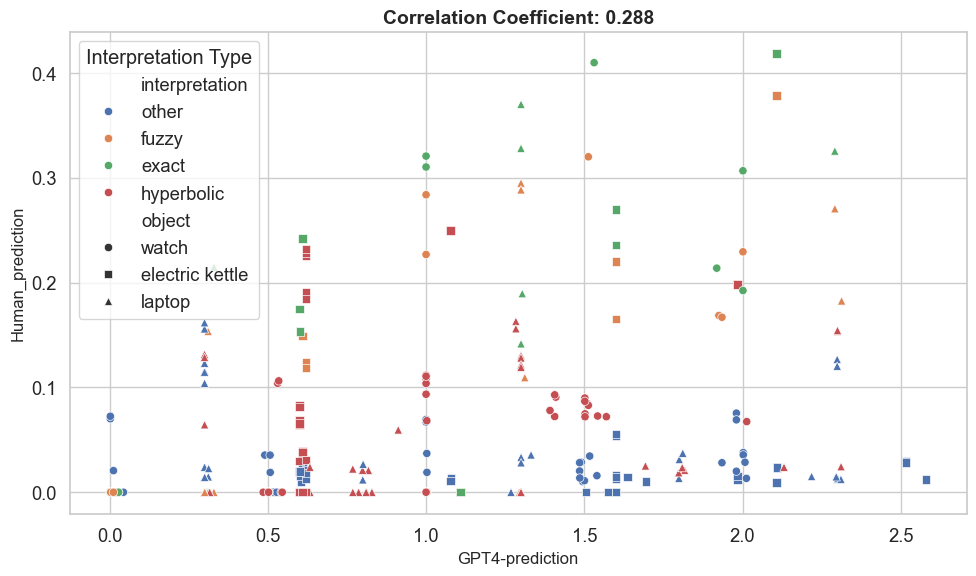

In [282]:
from scipy.stats import pearsonr
# replicate the plot from the write-up (fig 1, but with v2 data?)
# Compute the correlation coefficient
corr_coeff, _ = pearsonr(results_wHuman['posterior'], results_wHuman['human_prob'])

# Set the Seaborn theme
sns.set(style="whitegrid", font_scale=1.2)

# Create the scatter plot with regression line
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(
    data=results_wHuman,
    x='posterior',
    y='human_prob',
    hue='interpretation',  # Color by Interpretation Type
    style='object',  # Shape by Domain
    # height=6,
    # aspect=1.5,
    markers=['o', 's', '^', 'P'],  # Define marker shapes for each domain
    # scatter_kws={'s': 100},  # Customize scatter point size
    # ci=95  # Confidence interval for regression line
)

# Customize the plot
plt.title(f'Correlation Coefficient: {corr_coeff:.3f}', fontsize=14, weight='bold')
plt.xlabel('GPT4-prediction', fontsize=12)
plt.ylabel('Human_prediction', fontsize=12)
plt.tight_layout()

# Show the legend
plt.legend(title="Interpretation Type", loc="best", frameon=True)

# Display the plot
plt.show()